# 05 Analysis — Pareto Frontier: Train-time vs Inference-time Compute

**ВКР МИФИ, МП, Колотий М.П.**  
Модель: Qwen2.5-1.5B | Бенчмарки: GSM8K, MATH-500

## Структура
| Шаг | Описание |
|-----|----------|
| 0 | Setup: Drive, импорты, пути, логгер |
| 1 | Загрузка результатов (SFT / GRPO / Inference / Baseline) |
| 2 | Расчёт T_gen (средняя длина генерации из кэша) |
| 3 | Расчёт FLOPs для каждой точки |
| 4 | Парето-фронт (GSM8K и MATH-500 раздельно) |
| 5 | Визуализация: Парето при 3 × M, learning curve, val_loss scatter |
| 6 | Таблицы для ВКР: crossover, рекомендации |
| 7 | Экспорт PNG + JSON |

---
> **Формулы (раздел 3.1 ВКР)**  
> `C_SFT  = 6 × N × D_train`  
> `C_GRPO = 10 × N × D_GRPO`  (D_GRPO — токены генераций из лога TRL)
> `C_infer = 2 × N × T_gen × n`  
> `C_PRM  = 2 × N_PRM × T_eval × n`  
> `C_total = C_train / M + C_infer + C_PRM`

## Шаг 0 — Setup

In [1]:
# зависимости (если не установлены)
!pip install transformers -q

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

Mounted at /content/drive


In [3]:
import json
import logging
import os
import warnings
from pathlib import Path
from typing import Any

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings('ignore')
matplotlib.rcParams['figure.dpi'] = 150
matplotlib.rcParams['font.size'] = 11

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s  %(levelname)s  %(message)s',
    datefmt='%H:%M:%S',
)
log = logging.getLogger('analysis')
log.info('Imports OK')

In [4]:
# пути (синхронизация с 00_setup.ipynb)
DRIVE_ROOT   = Path('/content/drive/MyDrive')
VKR_ROOT     = DRIVE_ROOT / 'vkr_results'       # основная директория результатов
VKR_DATA     = DRIVE_ROOT / 'vkr_data'          # данные (data_stats.json)

SFT_DIR      = VKR_ROOT / 'sft'
GRPO_DIR     = VKR_ROOT / 'grpo'
INFER_DIR    = VKR_ROOT / 'inference'
GEN_DIR      = INFER_DIR / 'generations'
BASELINE_DIR = VKR_ROOT

OUT_ROOT     = Path('/content/results')
FIG_DIR      = OUT_ROOT / 'figures'
TAB_DIR      = OUT_ROOT / 'tables'
for d in (FIG_DIR, TAB_DIR):
    d.mkdir(parents=True, exist_ok=True)

log.info('Пути инициализированы')
log.info('  VKR_ROOT  = %s', VKR_ROOT)
log.info('  OUT_ROOT  = %s', OUT_ROOT)

In [5]:
# константы модели (раздел 3.1 ВКР)
N_STUDENT: int   = 1_540_000_000   # Qwen2.5-1.5B параметры
N_PRM: int       = 7_000_000_000   # Qwen2.5-Math-PRM-7B
N_EPOCHS: int    = 3               # эпохи SFT
G_GRPO: int      = 8               # генераций на промпт (GRPO)
K_GRPO: int      = 10              # множитель GRPO (верхняя оценка)

# режимы амортизации
M_MODES: dict[str, int | None] = {
    'M=|D_test|': None,            # заполняется динамически
    'M=10^4':     10_000,
    'M=10^5':     100_000,
}
D_TEST_SIZES: dict[str, int] = {'gsm8k': 1319, 'math500': 500}

BENCHMARKS:  list[str] = ['gsm8k', 'math500']
N_VALUES:    list[int] = [1, 4, 8, 16, 32]
STRATEGIES:  list[str] = ['majority_voting', 'best_of_n', 'weighted_voting']

log.info('Константы OK: N_STUDENT=%.2e  N_PRM=%.2e', N_STUDENT, N_PRM)

In [6]:
# токенизатор (для подсчёта T_gen)
from transformers import AutoTokenizer

TOKENIZER_ID = 'Qwen/Qwen2.5-1.5B'
tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_ID, trust_remote_code=True)
log.info('Tokenizer загружен: %s', TOKENIZER_ID)

config.json:   0%|          | 0.00/684 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

## Шаг 1 — Загрузка результатов

In [7]:
def load_json(path: Path) -> dict[str, Any]:
    """Загрузить JSON; вернуть {} если файл отсутствует."""
    if not path.exists():
        log.warning('Файл не найден: %s', path)
        return {}
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)


def parse_subset_name(name: str) -> tuple[int, int]:
    """'c2048_v500' → (cot_threshold=2048, volume=500).

    Использует regex для надёжного парсинга.
    Бросает ValueError при неверном формате.
    """
    import re
    m = re.match(r'^c(\d+)_v(\d+)$', name)
    if not m:
        raise ValueError(f'Неверный формат имени подмножества: {name!r}')
    return int(m.group(1)), int(m.group(2))

In [8]:
# data_stats.json: D_train по подмножествам
data_stats: dict[str, Any] = load_json(VKR_ROOT / 'data_stats.json')
if not data_stats:
    # fallback
    data_stats = load_json(Path('data_stats.json'))

log.info('data_stats: %d подмножеств', len(data_stats))
for k, v in data_stats.items():
    log.info('  %-18s  examples=%5d  total_tokens=%9d  avg=%4d',
             k, v['examples'], v['total_tokens'], v['avg_tokens'])

In [9]:
baseline: dict[str, Any] = load_json(BASELINE_DIR / 'baseline.json')
if not baseline:
    baseline = load_json(Path('baseline.json'))

log.info('Baseline GSM8K acc=%.3f  MATH acc=%.3f',
         baseline.get('gsm8k', {}).get('accuracy', float('nan')),
         baseline.get('math500', {}).get('accuracy', float('nan')))

In [10]:
import os
sft_dir = '/content/drive/MyDrive/vkr_results/sft'
files = os.listdir(sft_dir)
print(f'Файлов в sft/: {len(files)}')
print(files[:10])

Файлов в sft/: 2
['generations', 'c2048_v500_s42.json']


In [11]:
# SFT: 36 файлов → DataFrame
# Структура файла: {"gsm8k": {"accuracy": ..., "ci": [...], "none_rate": ...},
#                   "math500": {...}, "val_loss": ...}
SUBSETS = list(data_stats.keys())   # 12 подмножеств
SEEDS   = [42, 43, 44]

sft_rows: list[dict[str, Any]] = []
missing_sft: list[str] = []

for subset in SUBSETS:
    cot, vol = parse_subset_name(subset)
    for seed in SEEDS:
        fname = SFT_DIR / f'{subset}_s{seed}.json'
        data  = load_json(fname)
        if not data:
            missing_sft.append(str(fname))
            continue
        row: dict[str, Any] = {
            'model':   f'sft_{subset}_s{seed}',
            'subset':  subset,
            'cot':     cot,
            'volume':  vol,
            'seed':    seed,
            'type':    'sft',
        }
        for bench in BENCHMARKS:
            b = data.get(bench, {})
            row[f'{bench}_acc']       = b.get('accuracy', float('nan'))
            row[f'{bench}_ci_lo']     = b.get('ci', [float('nan'), float('nan')])[0]
            row[f'{bench}_ci_hi']     = b.get('ci', [float('nan'), float('nan')])[1]
            row[f'{bench}_none_rate'] = b.get('none_rate', float('nan'))
        row['val_loss'] = data.get('train', {}).get('final_val_loss', float('nan'))
        sft_rows.append(row)

df_sft = pd.DataFrame(sft_rows)
log.info('SFT загружено: %d / %d строк  (%d файлов отсутствует)',
         len(df_sft), len(SUBSETS) * len(SEEDS), len(missing_sft))
if missing_sft:
    for p in missing_sft[:5]:
        log.warning('  MISSING: %s', p)

df_sft.head()

,model,subset,cot,volume,seed,type,gsm8k_acc,gsm8k_ci_lo,gsm8k_ci_hi,gsm8k_none_rate,math500_acc,math500_ci_lo,math500_ci_hi,math500_none_rate,val_loss
0,sft_c2048_v500_s42,c2048_v500,2048,500,42,sft,0.414708,0.388173,0.442002,0.383624,0.264,0.226,0.302,0.548,0.678274


In [12]:
print(df_sft['val_loss'].values)

[0.67827433]


In [13]:
# GRPO: чекпоинты → DataFrame
# Структура файла из 03_grpo (v{volume}_best_ckpt{step}.json):
# {
#   "config": {"volume": 500, "sft_run": "c2048_v500_s42",
#              "grpo_step": 50, "max_steps": 2000, ...},
#   "gsm8k":  {"accuracy": ..., "ci": [...], "none_rate": ...},
#   "math500": {"accuracy": ..., "ci": [...], "none_rate": ...}
# }
grpo_rows: list[dict[str, Any]] = []

if GRPO_DIR.exists():
    for jf in sorted(GRPO_DIR.glob('v*_best_ckpt*.json')):
        data = load_json(jf)
        if not data:
            continue

        cfg     = data.get('config', {})
        volume  = cfg.get('volume', -1)
        sft_run = cfg.get('sft_run', '')   # e.g. 'c2048_v500_s42'
        step    = cfg.get('grpo_step', -1)

        # извлечь subset и seed из sft_run
        import re as _re
        m = _re.match(r'^(c\d+_v\d+)_s(\d+)$', sft_run)
        if m:
            subset = m.group(1)          # 'c2048_v500'
            seed   = int(m.group(2))     # 42
        else:
            log.warning('Не удалось разобрать sft_run=%r в %s', sft_run, jf.name)
            subset, seed = '', -1

        try:
            cot, vol = parse_subset_name(subset) if subset else (-1, volume)
        except ValueError:
            cot, vol = -1, volume

        row: dict[str, Any] = {
            'model':   f'grpo_v{volume}_step{step}',
            'subset':  subset,
            'sft_run': sft_run,
            'cot':     cot,
            'volume':  vol,
            'seed':    seed,
            'step':    step,
            'type':    'grpo',
        }
        for bench in BENCHMARKS:
            b = data.get(bench, {})
            row[f'{bench}_acc']   = b.get('accuracy', float('nan'))
            row[f'{bench}_ci_lo'] = b.get('ci', [float('nan'), float('nan')])[0]
            row[f'{bench}_ci_hi'] = b.get('ci', [float('nan'), float('nan')])[1]
            row[f'{bench}_none_rate'] = b.get('none_rate', float('nan'))
        grpo_rows.append(row)
else:
    log.warning('GRPO директория не найдена: %s', GRPO_DIR)

df_grpo = pd.DataFrame(grpo_rows) if grpo_rows else pd.DataFrame()
log.info('GRPO загружено: %d строк', len(df_grpo))
if not df_grpo.empty:
    display(df_grpo[['model', 'subset', 'volume', 'step',
                      'gsm8k_acc', 'math500_acc']].head(8))

In [14]:
import os
grpo_dir = '/content/drive/MyDrive/vkr_results/grpo'
print(os.listdir(grpo_dir))

['generations']


In [15]:
# Inference: inference_results.json
# Структура: {model_name: {
#   "majority_voting": {"gsm8k": {n: {"accuracy": ..., "ci": [...]}}, ...},
#   "best_of_n":       {...},
#   "weighted_voting": {...},
#   "config":          {...}
# }}
infer_raw: dict[str, Any] = load_json(INFER_DIR / 'inference_results.json')
log.info('Inference загружено: %d моделей', len(infer_raw))

infer_rows: list[dict[str, Any]] = []
for model_name, model_data in infer_raw.items():
    for strategy in STRATEGIES:
        strat_data = model_data.get(strategy, {})
        for bench in BENCHMARKS:
            bench_data = strat_data.get(bench, {})
            for n_str, metrics in bench_data.items():
                n = int(n_str)
                infer_rows.append({
                    'model':    model_name,
                    'strategy': strategy,
                    'bench':    bench,
                    'n':        n,
                    'accuracy': metrics.get('accuracy', float('nan')),
                    'ci_lo':    metrics.get('ci', [float('nan'), float('nan')])[0],
                    'ci_hi':    metrics.get('ci', [float('nan'), float('nan')])[1],
                })

df_infer = pd.DataFrame(infer_rows) if infer_rows else pd.DataFrame()
log.info('Inference строк: %d', len(df_infer))
if not df_infer.empty:
    display(df_infer.head(6))

,model,strategy,bench,n,accuracy,ci_lo,ci_hi
0,sft_c2048_v500_s42,majority_voting,gsm8k,1,0.414708,0.388173,0.442002
1,sft_c2048_v500_s42,majority_voting,gsm8k,4,0.592115,0.565580,0.619409
2,sft_c2048_v500_s42,majority_voting,gsm8k,8,0.704321,0.680061,0.728582
3,sft_c2048_v500_s42,majority_voting,gsm8k,16,0.762699,0.739196,0.786202
4,sft_c2048_v500_s42,majority_voting,gsm8k,32,0.799090,0.777104,0.820318
5,sft_c2048_v500_s42,majority_voting,math500,1,0.234000,0.198000,0.270000


## Шаг 2 — Расчёт T_gen (средняя длина генерации)

In [28]:
def compute_avg_tokens(
    texts: list[str],
    tokenizer,
    batch_size: int = 256,
) -> float:
    """Токенизировать список текстов, вернуть среднее число токенов.

    Параметры
    ----------
    texts      : список строк (тексты генераций)
    tokenizer  : HuggingFace tokenizer
    batch_size : размер батча для токенизации

    Возвращает
    ----------
    float : среднее число токенов T_gen
    """
    lengths: list[int] = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        enc   = tokenizer(batch, add_special_tokens=False, return_length=True)
        lengths.extend(enc['length'])
    return float(np.mean(lengths)) if lengths else 512.0


# Загружаем T_gen из кэшированных генераций
# Файл: generations/{model}_{bench}_n32.json
# Структура: {"generations": [[str, ...], ...]}
# или просто список строк / список списков.
T_gen: dict[str, dict[str, float]] = {}   # T_gen[model][bench]

if GEN_DIR.exists():
    for gen_file in sorted(GEN_DIR.glob('*_n32.json')):
        stem  = gen_file.stem           # e.g. sft_c2048_v500_s42_gsm8k_n32
        bench = 'gsm8k' if 'gsm8k' in stem else 'math500'
        # извлечь имя модели: убрать _{bench}_n32
        model = stem.replace(f'_{bench}_n32', '')

        raw = load_json(gen_file)
        if not raw:
            continue

        # нормализовать к flat list[str]
        gens = raw.get('generations', raw)
        flat: list[str] = []
        for item in gens:
            if isinstance(item, list):
                flat.extend([str(g) for g in item])
            else:
                flat.append(str(item))

        avg_t = compute_avg_tokens(flat, tokenizer)
        T_gen.setdefault(model, {})[bench] = avg_t
        log.info('T_gen  %-35s  %-8s  %.1f tokens', model, bench, avg_t)
else:
    log.warning('Директория генераций не найдена: %s', GEN_DIR)

log.info('T_gen загружен для %d моделей', len(T_gen))

In [29]:
# Fallback: если генерации недоступны — использовать медианные оценки
# Из 04_inference: GSM8K median=32 steps→~700 tok, MATH median=69 steps→~1500 tok
# (числа из диагностики ноутбука 04)
T_GEN_FALLBACK: dict[str, float] = {
    'gsm8k':   700.0,   # обновить из реальных данных
    'math500': 1500.0,  # обновить из реальных данных
}


def get_t_gen(model: str, bench: str) -> float:
    """Вернуть T_gen для модели/бенчмарка; при отсутствии — fallback."""
    return T_gen.get(model, {}).get(bench, T_GEN_FALLBACK[bench])


log.info('Fallback T_gen: GSM8K=%.0f  MATH=%.0f',
         T_GEN_FALLBACK['gsm8k'], T_GEN_FALLBACK['math500'])

In [30]:
print(f'GEN_DIR существует: {GEN_DIR.exists()}')
print(f'T_gen: {T_gen}')
print(f'Fallback GSM8K={T_GEN_FALLBACK["gsm8k"]}, MATH={T_GEN_FALLBACK["math500"]}')

GEN_DIR существует: True
T_gen: {'sft_c2048_v500_s42': {'gsm8k': 2044.8065769522366, 'math500': 4086.2194375}}
Fallback GSM8K=700.0, MATH=1500.0


## Шаг 3 — Расчёт FLOPs

In [31]:
def c_sft(subset: str) -> float:
    """C_SFT = 6 × N × D_train.

    D_train = total_tokens × n_epochs (все токены: промпт + ответ).
    LoRA экономит память, НЕ FLOPs — прямой/обратный проход через все N.
    Формула 6ND: Kaplan et al. [1], раздел 3.1 ВКР.
    """
    stats = data_stats.get(subset)
    if stats is None:
        log.warning('Подмножество не найдено в data_stats: %s', subset)
        return float('nan')
    d_train = stats['total_tokens'] * N_EPOCHS
    return 6.0 * N_STUDENT * d_train


def c_grpo(d_grpo: float, k: int = K_GRPO) -> float:
    """C_GRPO = K × N × D_GRPO.

    D_GRPO = num_tokens из training_log.json (TRL).
    K=10: генерация(2) + reference(2) + обновление(6).
    Совместимо с C_SFT=6ND, C_infer=2ND (Kaplan[1], Snell[4]).
    """
    return float(k) * N_STUDENT * d_grpo


def c_infer(t_gen: float, n: int) -> float:
    """C_infer = 2 × N × T_gen × n.

    Только forward pass (2 вместо 6).
    KV-cache снижает реальное время, не FLOPs этой формулы.
    """
    return 2.0 * N_STUDENT * t_gen * n


def c_prm(t_eval: float, n: int) -> float:
    """C_PRM = 2 × N_PRM × T_eval × n.

    T_eval ≈ T_gen (длина оцениваемой последовательности ≈ длина генерации).
    Применяется только для best_of_n и weighted_voting.
    """
    return 2.0 * N_PRM * t_eval * n


def c_total(
    train_flops: float,
    infer_flops: float,
    prm_flops: float,
    m: int,
) -> float:
    """C_total = C_train / M + C_infer + C_PRM.

    M — число задач при развёртывании (амортизирует стоимость обучения).
    Три режима: M = |D_test|, M = 10^4, M = 10^5.
    """
    return train_flops / m + infer_flops + prm_flops


log.info('Функции FLOPs определены')

In [32]:
# Добавить C_SFT к df_sft
if not df_sft.empty:
    df_sft['c_sft'] = df_sft['subset'].apply(c_sft)
    log.info('C_SFT рассчитан: мин=%.3e  макс=%.3e',
             df_sft['c_sft'].min(), df_sft['c_sft'].max())
    display(df_sft[['model', 'subset', 'volume', 'cot', 'c_sft',
                    'gsm8k_acc', 'math500_acc']].head(8))

,model,subset,volume,cot,c_sft,gsm8k_acc,math500_acc
0,sft_c2048_v500_s42,c2048_v500,500,2048,2.288086e+16,0.414708,0.264


In [33]:
# GRPO FLOPs: C_GRPO = 10 × N × D_GRPO
# D_GRPO = num_tokens из training_log.json до шага чекпоинта
GRPO_MODELS_PATH = Path('/content/drive/MyDrive/vkr_models/grpo')

def _read_num_tokens_at_step(volume: int, step: int) -> float | None:
    log_path = GRPO_MODELS_PATH / f'v{volume}_best' / 'training_log.json'
    if not log_path.exists():
        return None
    with open(log_path) as f:
        data = json.load(f)
    tokens = [e['num_tokens'] for e in data
              if 'num_tokens' in e and e.get('step', 0) <= step]
    return float(tokens[-1]) if tokens else None

if not df_grpo.empty:
    def _grpo_train_flops(row: pd.Series) -> float:
        d = _read_num_tokens_at_step(int(row['volume']), int(row.get('step', -1)))
        if d is None:
            log.warning('num_tokens недоступен: v%d step%d', row['volume'], row['step'])
            return float('nan')
        return c_sft(row['subset']) + c_grpo(d_grpo=d)

    df_grpo['c_train'] = df_grpo.apply(_grpo_train_flops, axis=1)
    log.info('C_train GRPO: %d строк, NaN=%d',
             len(df_grpo), int(df_grpo['c_train'].isna().sum()))
else:
    log.info('df_grpo пуст — GRPO FLOPs пропущены')

In [34]:
# Добавить FLOPs к df_infer
def _needs_prm(strategy: str) -> bool:
    return strategy in ('best_of_n', 'weighted_voting')


if not df_infer.empty:
    def _add_flops(row: pd.Series) -> pd.Series:
        tg = get_t_gen(row['model'], row['bench'])
        ci = tg   # T_eval ≈ T_gen
        n  = row['n']

        row['t_gen']      = tg
        row['c_infer']    = c_infer(tg, n)
        row['c_prm']      = c_prm(ci, n) if _needs_prm(row['strategy']) else 0.0

        # C_train берём из df_sft по имени модели (SFT-часть)
        sft_match = df_sft[df_sft['model'] == row['model']] if not df_sft.empty else pd.DataFrame()
        row['c_train'] = sft_match['c_sft'].iloc[0] if not sft_match.empty else float('nan')
        return row

    df_infer = df_infer.apply(_add_flops, axis=1)
    log.info('FLOPs добавлены в df_infer')
    display(df_infer[['model', 'strategy', 'bench', 'n',
                       'accuracy', 'c_train', 'c_infer', 'c_prm']].head(6))

,model,strategy,bench,n,accuracy,c_train,c_infer,c_prm
0,sft_c2048_v500_s42,majority_voting,gsm8k,1,0.414708,2.288086e+16,6.298004e+12,0.0
1,sft_c2048_v500_s42,majority_voting,gsm8k,4,0.592115,2.288086e+16,2.519202e+13,0.0
2,sft_c2048_v500_s42,majority_voting,gsm8k,8,0.704321,2.288086e+16,5.038403e+13,0.0
3,sft_c2048_v500_s42,majority_voting,gsm8k,16,0.762699,2.288086e+16,1.007681e+14,0.0
4,sft_c2048_v500_s42,majority_voting,gsm8k,32,0.799090,2.288086e+16,2.015361e+14,0.0
5,sft_c2048_v500_s42,majority_voting,math500,1,0.234000,2.288086e+16,1.258556e+13,0.0


In [35]:
# Рассчитать C_total для трёх режимов M
# C_total — итоговая стоимость в FLOPs на одну задачу при развёртывании:
def add_c_total_columns(df: pd.DataFrame, m_modes: dict[str, int | None]) -> pd.DataFrame:
    """Добавить столбцы c_total_{mode} для каждого режима M."""
    df = df.copy()
    for label, m_val in m_modes.items():
        col = f'c_total_{label}'

        def _row_total(row: pd.Series) -> float:
            bench  = row.get('bench', 'gsm8k')
            m      = m_val if m_val is not None else D_TEST_SIZES.get(bench, 500)
            train  = row.get('c_train', 0.0)
            infer  = row.get('c_infer', 0.0)
            prm    = row.get('c_prm', 0.0)
            if np.isnan(train):
                return float('nan')
            return c_total(train, infer, prm, m)

        df[col] = df.apply(_row_total, axis=1)
    return df


if not df_infer.empty:
    df_infer = add_c_total_columns(df_infer, M_MODES)
    log.info('C_total столбцы добавлены: %s', [c for c in df_infer.columns if 'c_total' in c])

In [36]:
print(df_infer[[c for c in df_infer.columns if 'c_total' in c]].head(3))
print()
# Проверим одну точку вручную: n=1, majority_voting, gsm8k
row = df_infer[(df_infer['n']==1) &
               (df_infer['strategy']=='majority_voting') &
               (df_infer['bench']=='gsm8k')].iloc[0]
print(f'c_train:  {row["c_train"]:.3e}')
print(f'c_infer:  {row["c_infer"]:.3e}')
print(f'c_prm:    {row["c_prm"]:.3e}')
print()
for label, m_val in M_MODES.items():
    m = m_val if m_val is not None else 1319
    expected = row['c_train']/m + row['c_infer'] + row['c_prm']
    actual = row[f'c_total_{label}']
    ok = '✓' if abs(expected - actual) < 1 else '✗'
    print(f'{label}: ожидалось {expected:.3e}, получилось {actual:.3e}  {ok}')

   c_total_M=|D_test|  c_total_M=10^4  c_total_M=10^5
0        2.364513e+13    8.586091e+12    6.526813e+12
1        4.253915e+13    2.748010e+13    2.542083e+13
2        6.773116e+13    5.267212e+13    5.061284e+13

c_train:  2.288e+16
c_infer:  6.298e+12
c_prm:    0.000e+00

M=|D_test|: ожидалось 2.365e+13, получилось 2.365e+13  ✓
M=10^4: ожидалось 8.586e+12, получилось 8.586e+12  ✓
M=10^5: ожидалось 6.527e+12, получилось 6.527e+12  ✓


In [37]:
# При каком M обучение становится пренебрежимым?
c_train = row['c_train']  # 2.288e+16
c_infer_n1 = row['c_infer']  # 6.298e+12

# Доля C_train/M в C_total для каждого M
for label, m_val in M_MODES.items():
    m = m_val if m_val is not None else 1319
    train_share = (c_train / m) / (c_train / m + c_infer_n1)
    print(f'{label} (M={m:>7d}): доля обучения = {train_share:.1%}')

print()
# При каком M обучение < 10% от total?
m_crossover = c_train / (0.1 * c_infer_n1) * 0.1 / 0.9
print(f'Обучение < 10% при M > {c_train / (9 * c_infer_n1):.0f}')

M=|D_test| (M=   1319): доля обучения = 73.4%
M=10^4 (M=  10000): доля обучения = 26.6%
M=10^5 (M= 100000): доля обучения = 3.5%

Обучение < 10% при M > 404


## Шаг 4 — Парето-фронт

In [38]:
def pareto_frontier(
    flops: np.ndarray,
    accuracy: np.ndarray,
) -> np.ndarray:
    """Вернуть булев массив: True = точка Парето-оптимальна.

    Точка доминируется, если существует другая с меньшими FLOPs И большей accuracy.
    Оптимизация: max accuracy при min cost.
    """
    n = len(flops)
    is_pareto = np.ones(n, dtype=bool)
    for i in range(n):
        if not is_pareto[i]:
            continue
        # доминируется ли точка i?
        dominated = (
            (flops <= flops[i]) & (accuracy >= accuracy[i]) &
            ((flops < flops[i]) | (accuracy > accuracy[i]))
        )
        if dominated.any():
            is_pareto[i] = False
    return is_pareto


log.info('Pareto функции определены')

In [39]:
# Собрать все точки: (bench, strategy, model, n, flops_M, accuracy)
# для каждого режима M

pareto_data: dict[str, dict[str, pd.DataFrame]] = {}
# pareto_data[bench][m_label] → DataFrame с колонками [model, strategy, n, flops, accuracy]

for bench in BENCHMARKS:
    pareto_data[bench] = {}

    for m_label in M_MODES:
        flops_col = f'c_total_{m_label}'
        rows: list[dict[str, Any]] = []
        m_val = M_MODES[m_label]  # определяем здесь — используется в SFT и GRPO блоках

        if not df_infer.empty and flops_col in df_infer.columns:
            sub = df_infer[df_infer['bench'] == bench].copy()
            for _, row in sub.iterrows():
                if not np.isnan(row[flops_col]) and not np.isnan(row['accuracy']):
                    rows.append({
                        'model':    row['model'],
                        'strategy': row['strategy'],
                        'n':        row['n'],
                        'flops':    row[flops_col],
                        'accuracy': row['accuracy'],
                        'ci_lo':    row.get('ci_lo', float('nan')),
                        'ci_hi':    row.get('ci_hi', float('nan')),
                    })

        # SFT greedy (n=1): C_total = C_SFT/M + C_infer(n=1)
        # C_infer(n=1) обязателен — deployed inference всегда стоит forward pass.
        # Без него SFT greedy искусственно дешевле inference-точек → Pareto смещён.
        if not df_sft.empty:
            acc_col  = f'{bench}_acc'
            cilo_col = f'{bench}_ci_lo'
            cihi_col = f'{bench}_ci_hi'
            for _, row in df_sft.iterrows():
                if np.isnan(row[acc_col]):
                    continue
                m_eff = m_val if m_val is not None else D_TEST_SIZES[bench]
                tg    = get_t_gen(row['model'], bench)
                rows.append({
                    'model':    row['model'],
                    'strategy': 'sft_greedy',
                    'n':        1,
                    'flops':    row['c_sft'] / m_eff + c_infer(tg, 1),
                    'accuracy': row[acc_col],
                    'ci_lo':    row.get(cilo_col, float('nan')),
                    'ci_hi':    row.get(cihi_col, float('nan')),
                })

        df_pts = pd.DataFrame(rows) if rows else pd.DataFrame()

        # GRPO greedy (n=1): C_total = C_train(SFT+GRPO)/M + C_infer(n=1)
        # Каждый чекпоинт — отдельная точка на Парето-фронте.
        if not df_grpo.empty and 'c_train' in df_grpo.columns:
            acc_col_g  = f'{bench}_acc'
            cilo_col_g = f'{bench}_ci_lo'
            cihi_col_g = f'{bench}_ci_hi'
            grpo_extra: list[dict[str, Any]] = []
            for _, grow in df_grpo.iterrows():
                if np.isnan(grow.get(acc_col_g, float('nan'))):
                    continue
                if np.isnan(grow.get('c_train', float('nan'))):
                    continue
                tg_g  = get_t_gen(grow['model'], bench)
                m_eff = m_val if m_val is not None else D_TEST_SIZES[bench]
                grpo_extra.append({
                    'model':    grow['model'],
                    'strategy': 'grpo_greedy',
                    'n':        1,
                    'flops':    grow['c_train'] / m_eff + c_infer(tg_g, 1),
                    'accuracy': grow[acc_col_g],
                    'ci_lo':    grow.get(cilo_col_g, float('nan')),
                    'ci_hi':    grow.get(cihi_col_g, float('nan')),
                })
            if grpo_extra:
                df_pts = pd.concat([df_pts, pd.DataFrame(grpo_extra)], ignore_index=True)

        if not df_pts.empty:
            mask = pareto_frontier(df_pts['flops'].values, df_pts['accuracy'].values)
            df_pts['is_pareto'] = mask
        pareto_data[bench][m_label] = df_pts
        log.info('Парето точек [%s][%s]: %d  (Парето-опт.: %d)',
                 bench, m_label, len(df_pts),
                 int(df_pts['is_pareto'].sum()) if not df_pts.empty else 0)

log.info('Парето-данные собраны')

In [40]:
# Первый бюджет где стратегия превосходит SFT greedy.
# Проверяются: inference-стратегии (majority_voting, best_of_n, weighted_voting)
# и GRPO greedy (каждый чекпоинт = отдельная точка при n=1).
# ТЕРМИН: 'first_budget' — пороговая эвристика на дискретной сетке,
# не строгое пересечение фронтов. Согласовано с разделом 2.3 ВКР.
first_budget_results: list[dict[str, Any]] = []

# Inference + GRPO — всё сравниваем против SFT greedy
STRATEGIES_TO_COMPARE = STRATEGIES + ['grpo_greedy']

for bench in BENCHMARKS:
    for m_label in M_MODES:
        df_pts = pareto_data[bench].get(m_label, pd.DataFrame())
        if df_pts.empty:
            continue

        df_sft_pts = df_pts[df_pts['strategy'] == 'sft_greedy'].copy()
        for strategy in STRATEGIES_TO_COMPARE:
            df_strat = df_pts[df_pts['strategy'] == strategy].copy()
            if df_sft_pts.empty or df_strat.empty:
                continue

            for n in sorted(df_strat['n'].unique()):
                # сортировка по flops обязательна — ищем ПЕРВЫЙ бюджет
                df_n = df_strat[df_strat['n'] == n].sort_values('flops')
                for _, cand_row in df_n.iterrows():
                    cheaper_sft = df_sft_pts[df_sft_pts['flops'] <= cand_row['flops']]
                    if cheaper_sft.empty:
                        continue
                    best_sft_acc = cheaper_sft['accuracy'].max()
                    if cand_row['accuracy'] > best_sft_acc:
                        first_budget_results.append({
                            'bench':              bench,
                            'M_mode':             m_label,
                            'strategy':           strategy,
                            'n':                  n,
                            'first_budget_flops': cand_row['flops'],
                            'cand_acc':           cand_row['accuracy'],
                            'sft_acc':            best_sft_acc,
                            'delta':              cand_row['accuracy'] - best_sft_acc,
                        })
                        break  # первый бюджет найден для этой стратегии/n

df_first_budget = pd.DataFrame(first_budget_results)
log.info('Первых бюджетов найдено: %d', len(df_first_budget))
if not df_first_budget.empty:
    display(df_first_budget.sort_values(['bench', 'M_mode', 'strategy', 'n']))

,bench,M_mode,strategy,n,first_budget_flops,cand_acc,sft_acc,delta
16,gsm8k,M=10^4,best_of_n,4,1.419893e+14,0.595148,0.414708,0.180440
17,gsm8k,M=10^4,best_of_n,8,2.816905e+14,0.664139,0.414708,0.249431
18,gsm8k,M=10^4,best_of_n,16,5.610928e+14,0.710387,0.414708,0.295679
19,gsm8k,M=10^4,best_of_n,32,1.119898e+15,0.746778,0.414708,0.332070
12,gsm8k,M=10^4,majority_voting,4,2.748010e+13,0.592115,0.414708,0.177407
...,...,...,...,...,...,...,...,...
39,math500,M=|D_test|,majority_voting,32,4.484995e+14,0.492000,0.264000,0.228000
44,math500,M=|D_test|,weighted_voting,4,3.249322e+14,0.360000,0.264000,0.096000
45,math500,M=|D_test|,weighted_voting,8,6.041028e+14,0.412000,0.264000,0.148000
46,math500,M=|D_test|,weighted_voting,16,1.162444e+15,0.442000,0.264000,0.178000


## Шаг 5 — Визуализация

In [41]:
# Цветовая схема стратегий (консистентна во всех графиках)
STRATEGY_STYLE: dict[str, dict[str, Any]] = {
    'majority_voting':  {'color': '#1f77b4', 'marker': 'o', 'label': 'Majority Voting'},
    'best_of_n':        {'color': '#ff7f0e', 'marker': 's', 'label': 'Best-of-N (PRM)'},
    'weighted_voting':  {'color': '#2ca02c', 'marker': '^', 'label': 'Weighted Voting'},
    'sft_greedy':       {'color': '#9467bd', 'marker': 'D', 'label': 'SFT greedy (n=1)'},
    'grpo_greedy':      {'color': '#d62728', 'marker': 'P', 'label': 'GRPO greedy (n=1)'},
    'baseline':         {'color': '#7f7f7f', 'marker': '*', 'label': 'Baseline (Qwen2.5-1.5B)'},
}

BENCH_LABEL: dict[str, str] = {'gsm8k': 'GSM8K', 'math500': 'MATH-500'}

def savefig(fig: plt.Figure, name: str) -> None:
    """Сохранить фигуру в FIG_DIR с 150 dpi."""
    path = FIG_DIR / f'{name}.png'
    fig.savefig(path, dpi=150, bbox_inches='tight')
    log.info('Сохранено: %s', path)

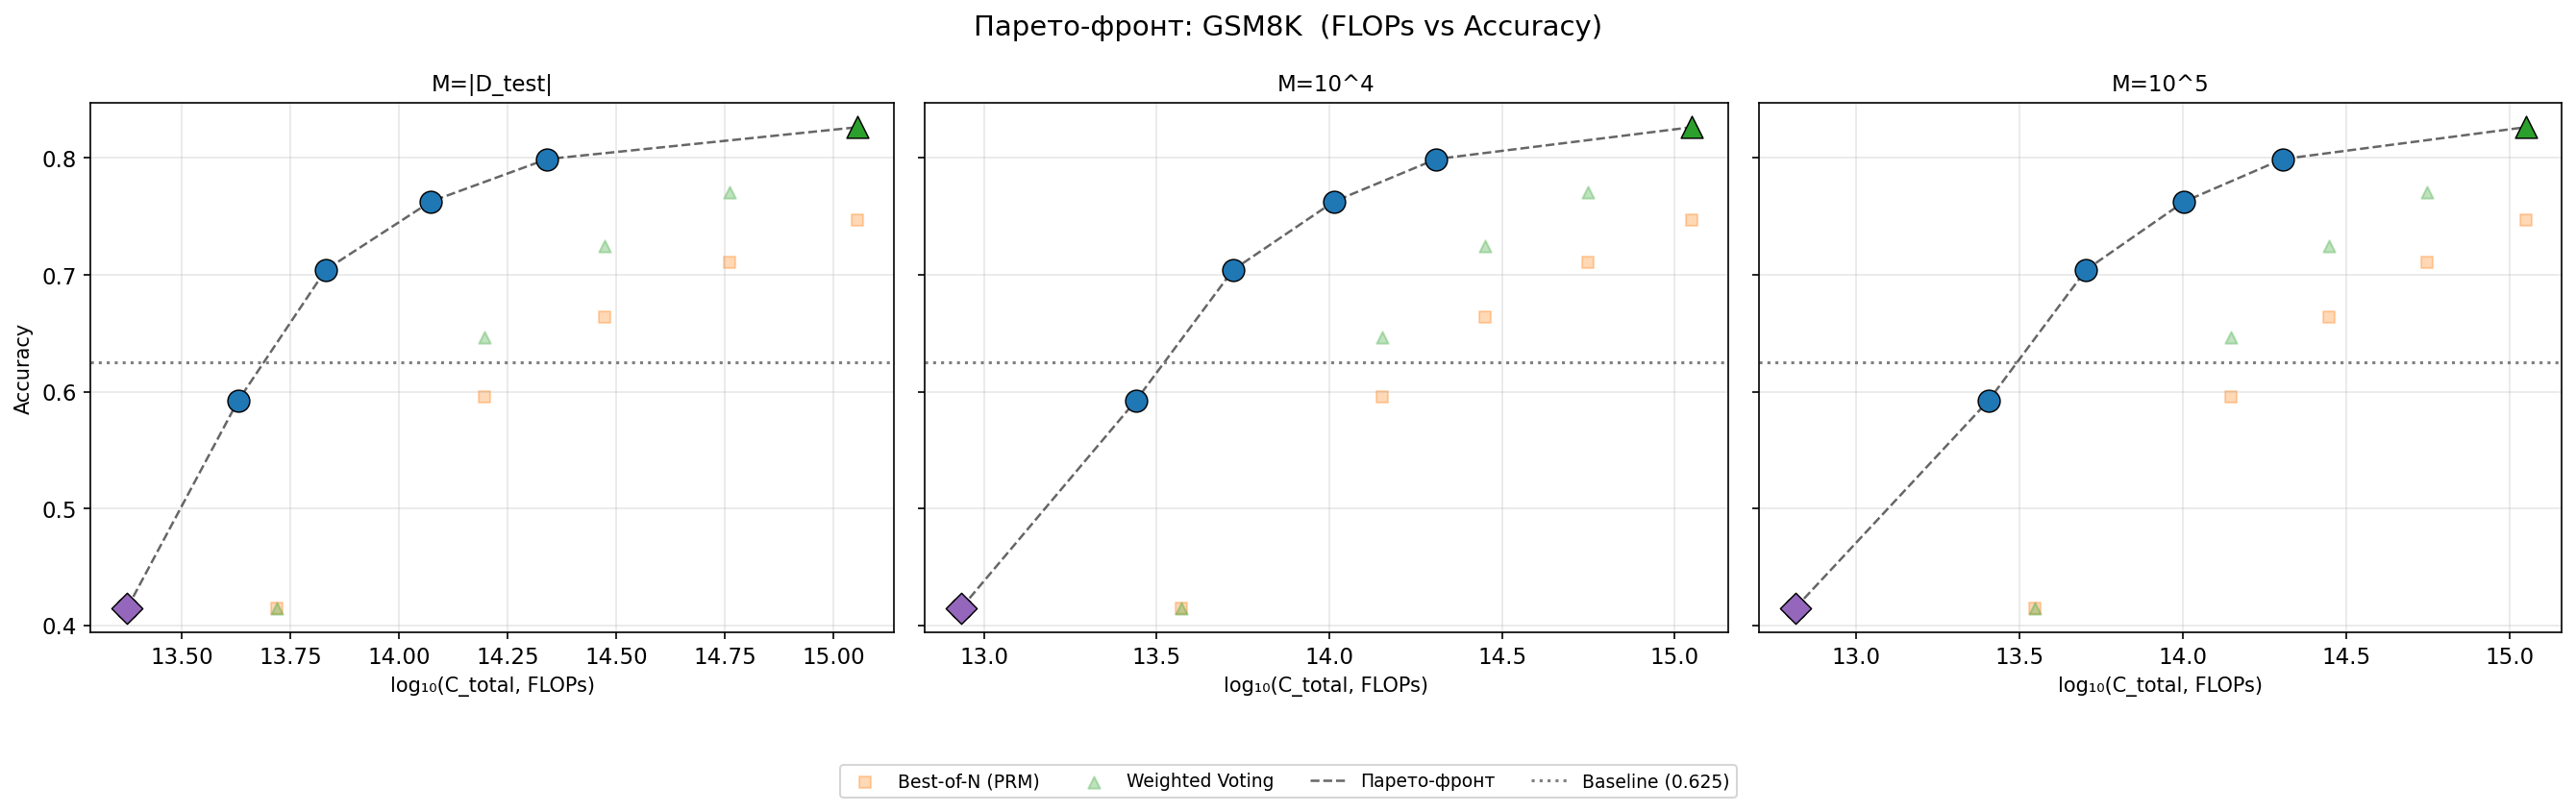

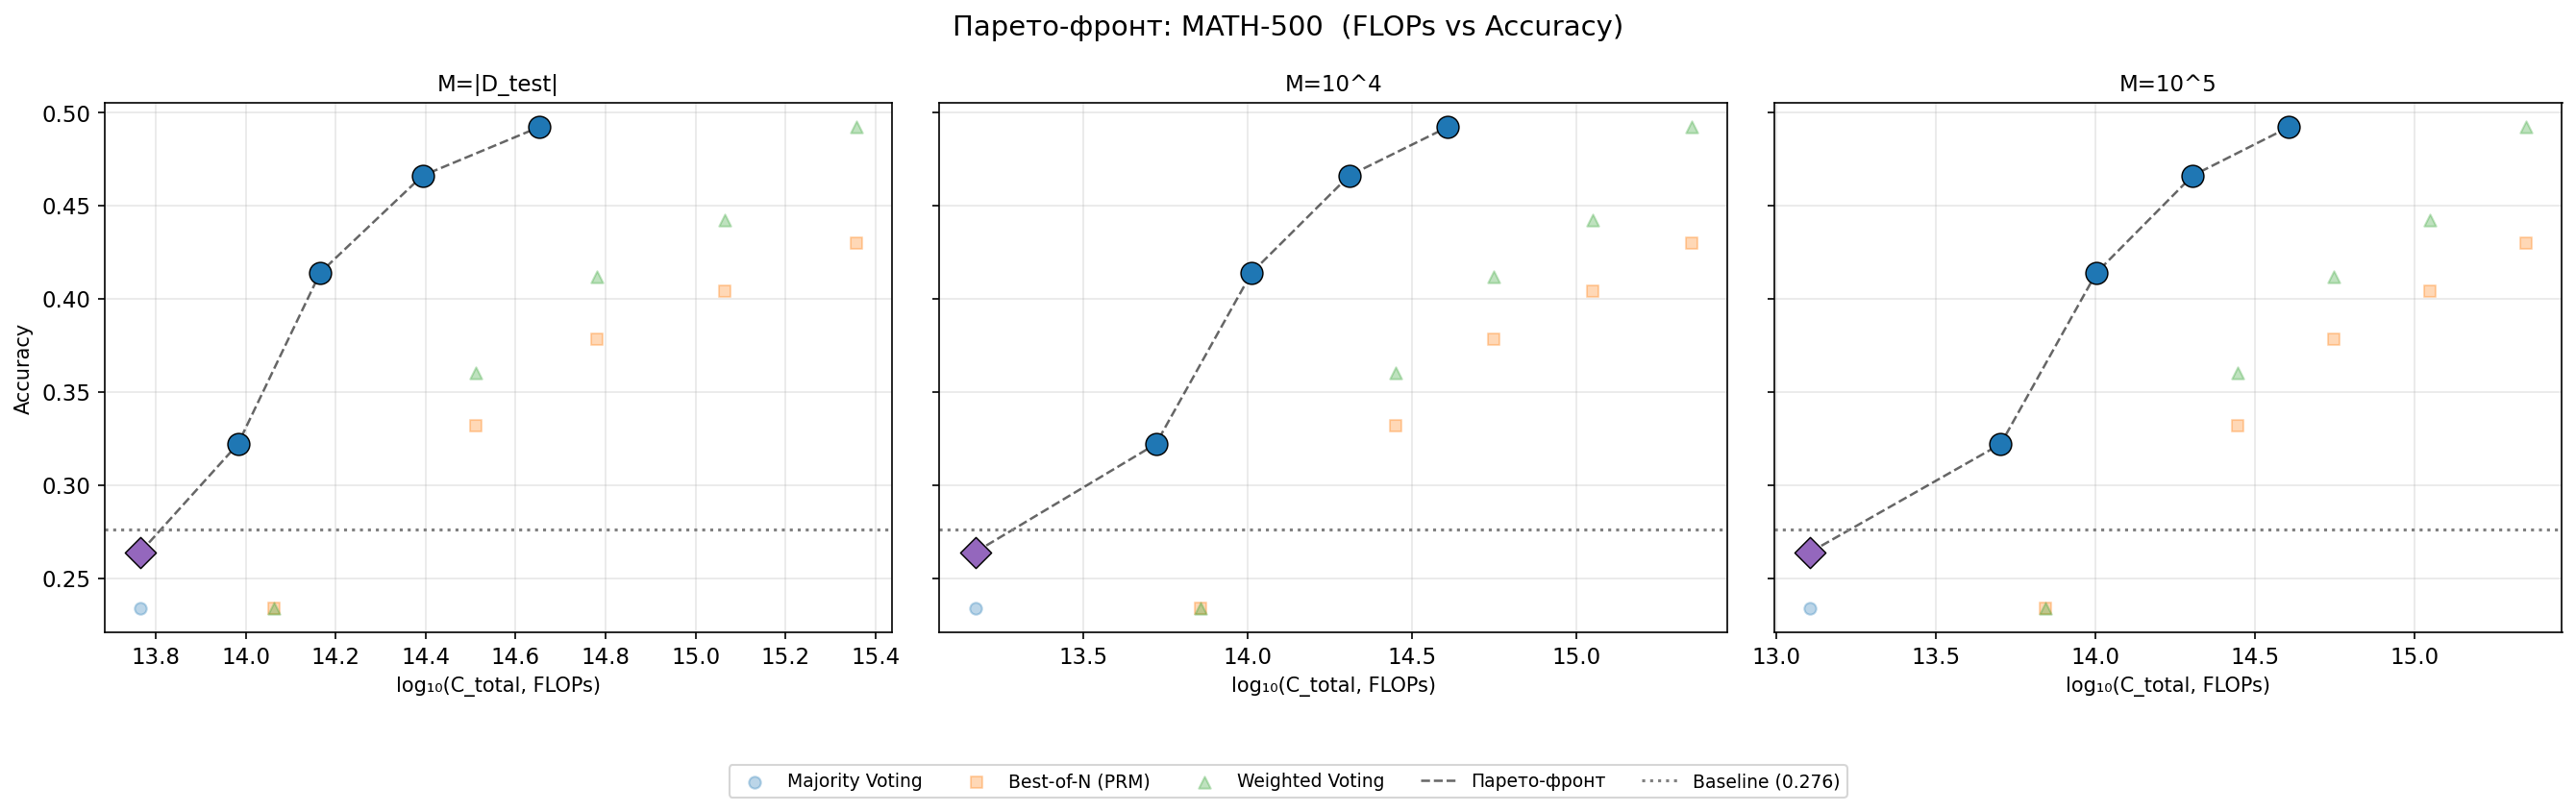

In [42]:
# 5.1 Парето-фронт: 3 × M, 2 × benchmark
m_labels = list(M_MODES.keys())

for bench in BENCHMARKS:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
    fig.suptitle(f'Парето-фронт: {BENCH_LABEL[bench]}  (FLOPs vs Accuracy)', fontsize=14)

    for ax, m_label in zip(axes, m_labels):
        df_pts = pareto_data[bench].get(m_label, pd.DataFrame())
        bl_acc = baseline.get(bench, {}).get('accuracy', None)

        if df_pts.empty:
            ax.set_title(m_label)
            ax.text(0.5, 0.5, 'Данные отсутствуют', ha='center', va='center',
                    transform=ax.transAxes, color='gray')
            continue

        # scatter: не-Парето точки (полупрозрачные)
        df_non_pareto = df_pts[~df_pts['is_pareto']]
        for strategy in df_non_pareto['strategy'].unique():
            st  = STRATEGY_STYLE.get(strategy, {'color': '#aaaaaa', 'marker': '.', 'label': strategy})
            sub = df_non_pareto[df_non_pareto['strategy'] == strategy]
            ax.scatter(
                np.log10(sub['flops'].values),
                sub['accuracy'].values,
                c=st['color'], marker=st['marker'],
                alpha=0.3, s=35, label=st['label'],
            )

        # Парето-оптимальные точки (яркие, соединённые линией)
        pf = df_pts[df_pts['is_pareto']].sort_values('flops')
        if not pf.empty:
            ax.plot(
                np.log10(pf['flops'].values),
                pf['accuracy'].values,
                'k--', linewidth=1.2, alpha=0.6, label='Парето-фронт',
            )
            for _, row in pf.iterrows():
                st = STRATEGY_STYLE.get(row['strategy'],
                                        {'color': 'k', 'marker': 'o'})
                ax.scatter(
                    np.log10(row['flops']),
                    row['accuracy'],
                    c=st['color'], marker=st['marker'],
                    s=120, zorder=5, edgecolors='k', linewidths=0.7,
                )

        # baseline
        if bl_acc is not None:
            ax.axhline(bl_acc, color='gray', linestyle=':', linewidth=1.5,
                       label=f'Baseline ({bl_acc:.3f})')

        ax.set_title(m_label, fontsize=11)
        ax.set_xlabel('log₁₀(C_total, FLOPs)', fontsize=10)
        ax.grid(True, alpha=0.3)

    axes[0].set_ylabel('Accuracy', fontsize=10)

    # единая легенда — без дублей
    handles, labels = [], []
    seen: set[str] = set()
    for ax in axes:
        for h, l in zip(*ax.get_legend_handles_labels()):
            if l not in seen:
                handles.append(h); labels.append(l); seen.add(l)
    fig.legend(handles, labels, loc='lower center', ncol=5,
               bbox_to_anchor=(0.5, -0.12), fontsize=9)

    plt.tight_layout()
    savefig(fig, f'pareto_{bench}')
    plt.show()

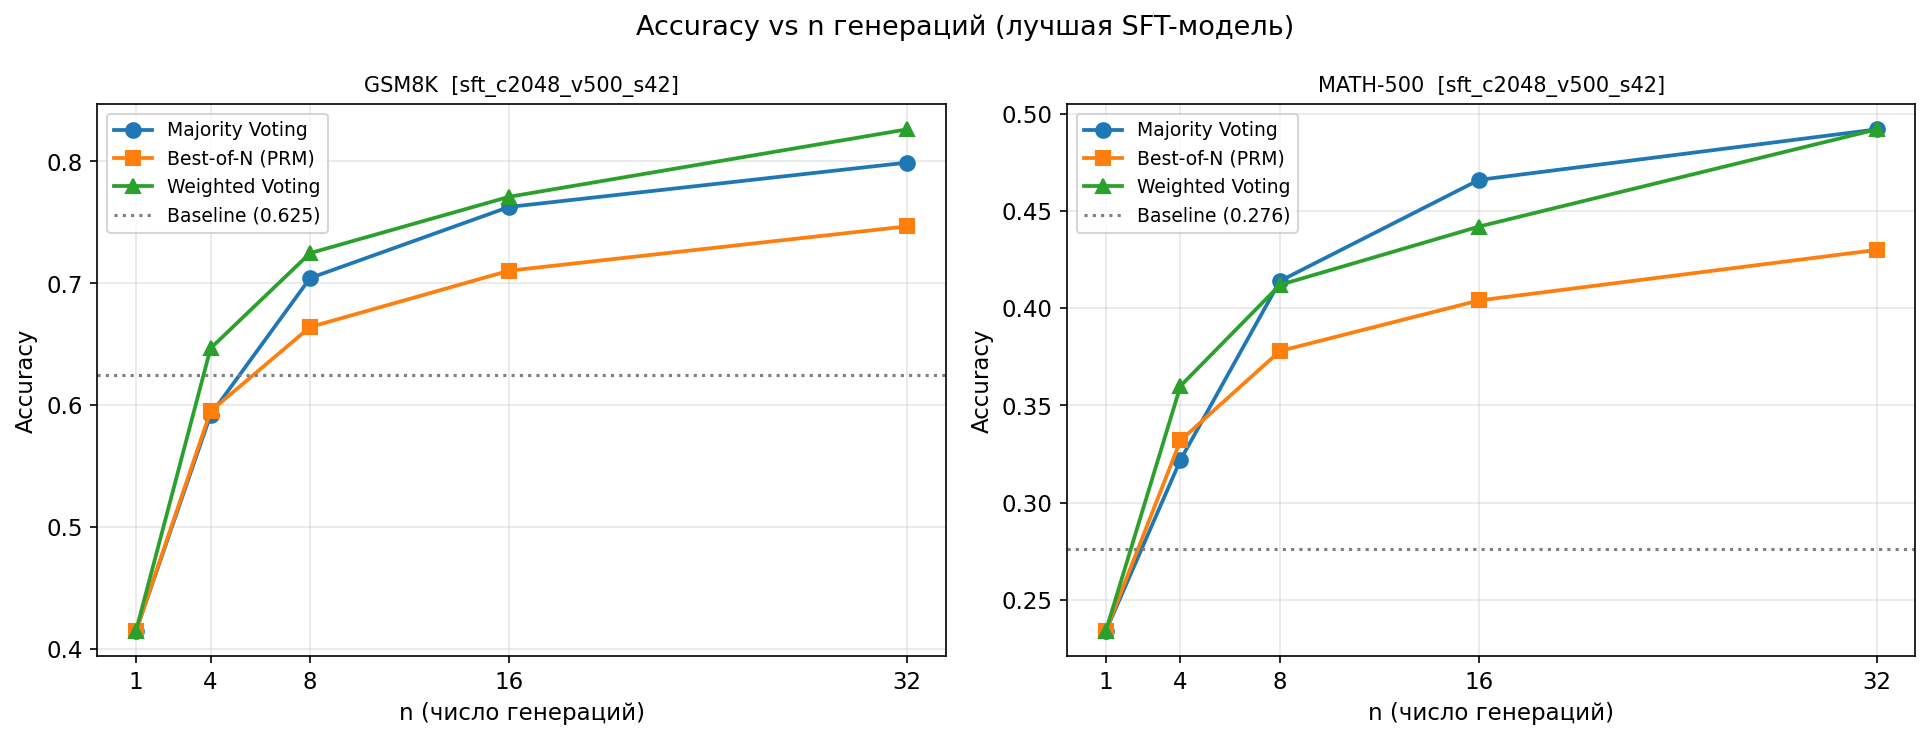

In [43]:
# 5.2 Accuracy vs n для каждой стратегии (лучшая SFT-модель)
if not df_infer.empty:
    # выбрать лучшую модель по accuracy при n=1 на каждом бенчмарке
    best_models: dict[str, str] = {}
    for bench in BENCHMARKS:
        sub_n1 = df_infer[(df_infer['bench'] == bench) & (df_infer['n'] == 1)]
        if sub_n1.empty:
            continue
        best_models[bench] = sub_n1.loc[sub_n1['accuracy'].idxmax(), 'model']
        log.info('Лучшая модель [%s]: %s', bench, best_models[bench])

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle('Accuracy vs n генераций (лучшая SFT-модель)', fontsize=13)

    for ax, bench in zip(axes, BENCHMARKS):
        model = best_models.get(bench)
        if model is None:
            ax.set_title(BENCH_LABEL[bench])
            continue

        sub = df_infer[(df_infer['model'] == model) & (df_infer['bench'] == bench)]
        for strategy in STRATEGIES:
            st = STRATEGY_STYLE[strategy]
            pts = sub[sub['strategy'] == strategy].sort_values('n')
            if pts.empty:
                continue
            ax.plot(pts['n'], pts['accuracy'],
                    color=st['color'], marker=st['marker'],
                    label=st['label'], linewidth=1.8, markersize=7)

        # baseline
        bl_acc = baseline.get(bench, {}).get('accuracy')
        if bl_acc:
            ax.axhline(bl_acc, color='gray', linestyle=':', linewidth=1.5,
                       label=f'Baseline ({bl_acc:.3f})')

        ax.set_title(f'{BENCH_LABEL[bench]}  [{model}]', fontsize=10)
        ax.set_xlabel('n (число генераций)')
        ax.set_ylabel('Accuracy')
        ax.set_xticks(N_VALUES)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=9)

    plt.tight_layout()
    savefig(fig, 'accuracy_vs_n')
    plt.show()

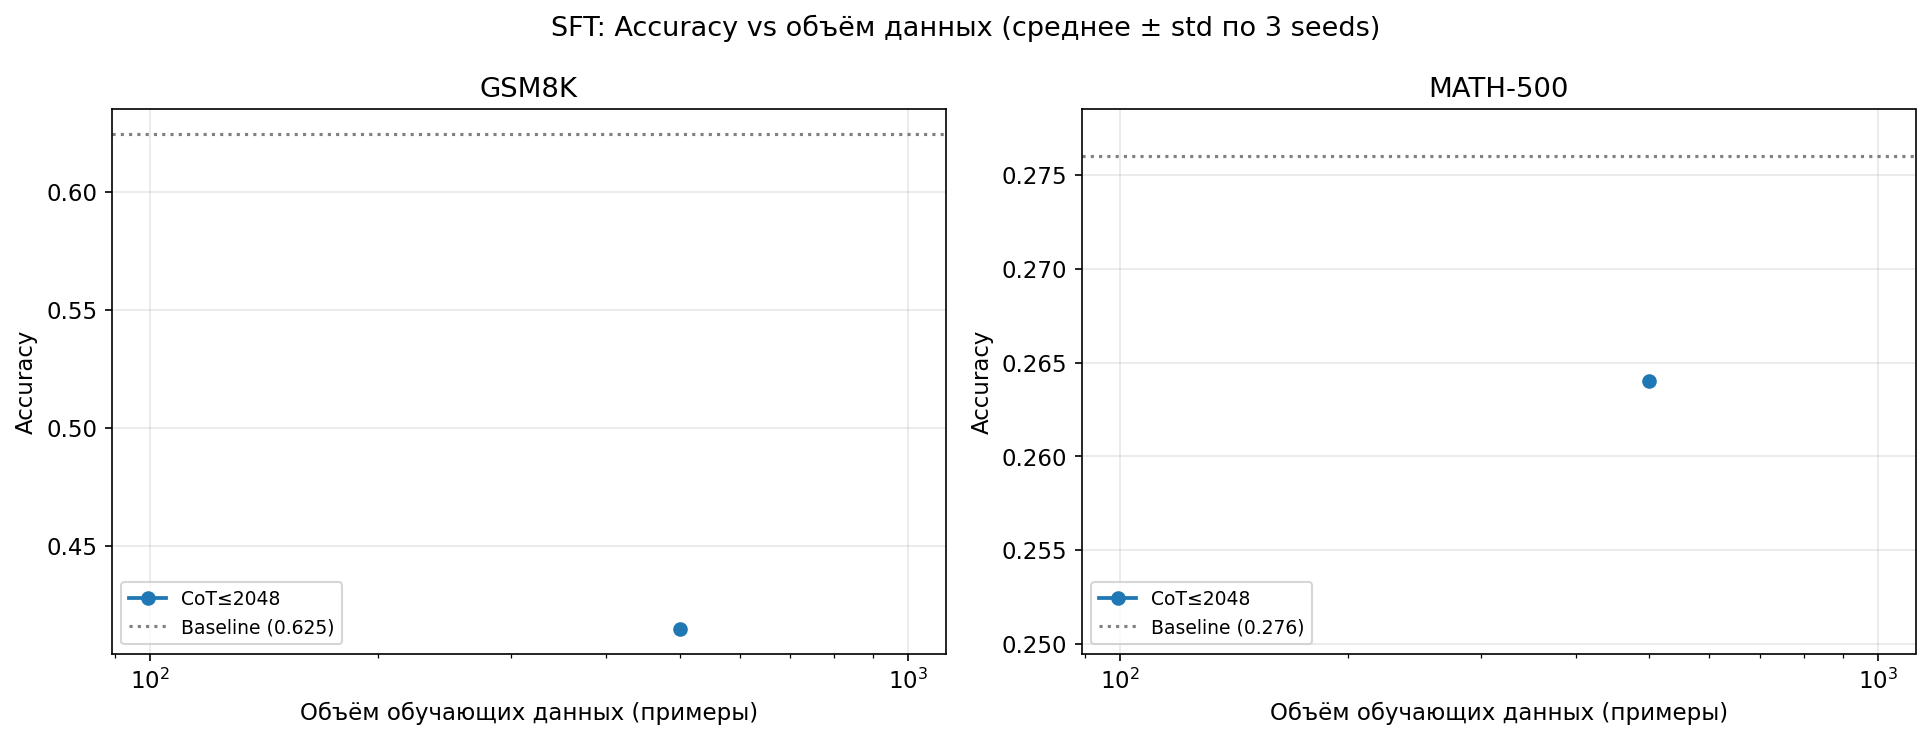

In [47]:
# 5.3 SFT learning curve: accuracy vs volume (усреднение по seeds)
if not df_sft.empty:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle('SFT: Accuracy vs объём данных (среднее ± std по 3 seeds)', fontsize=13)

    for ax, bench in zip(axes, BENCHMARKS):
        acc_col = f'{bench}_acc'
        for cot, group in df_sft.groupby('cot'):
            agg = (
                group.groupby('volume')[acc_col]
                .agg(['mean', 'std'])
                .reset_index()
                .sort_values('volume')
            )
            ax.plot(agg['volume'], agg['mean'],
                    marker='o', label=f'CoT≤{cot}', linewidth=1.8)
            ax.fill_between(
                agg['volume'],
                agg['mean'] - agg['std'],
                agg['mean'] + agg['std'],
                alpha=0.15,
            )

        bl_acc = baseline.get(bench, {}).get('accuracy')
        if bl_acc:
            ax.axhline(bl_acc, color='gray', linestyle=':', linewidth=1.5,
                       label=f'Baseline ({bl_acc:.3f})')

        ax.set_title(BENCH_LABEL[bench])
        ax.set_xlabel('Объём обучающих данных (примеры)')
        ax.set_ylabel('Accuracy')
        ax.set_xscale('log')
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=9)

    plt.tight_layout()
    savefig(fig, 'sft_learning_curve')
    plt.show()

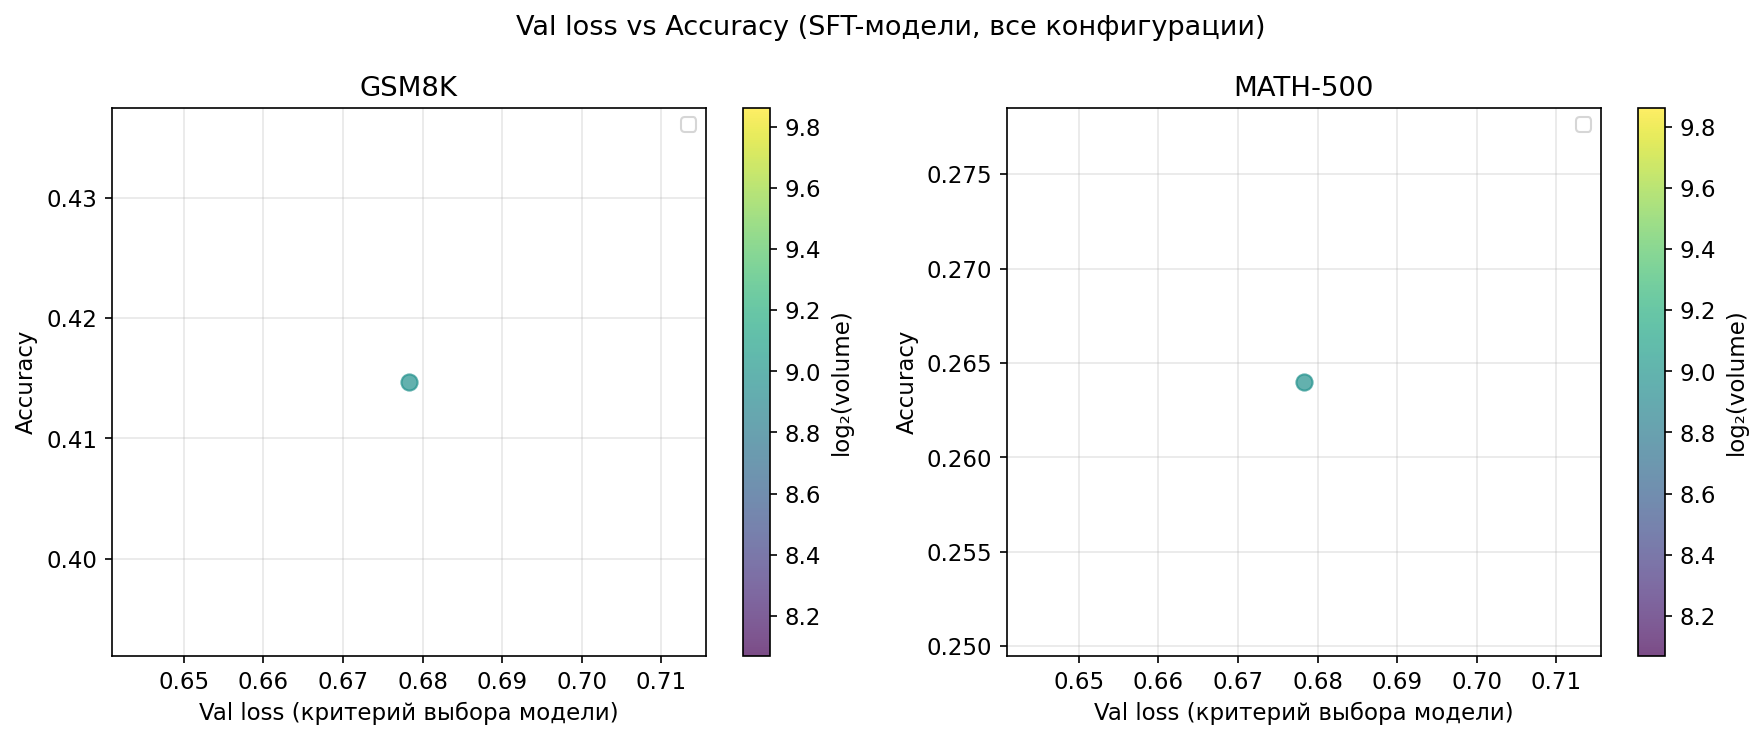

In [48]:
# 5.4 Val loss vs Accuracy scatter
if not df_sft.empty and 'val_loss' in df_sft.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle('Val loss vs Accuracy (SFT-модели, все конфигурации)', fontsize=13)

    for ax, bench in zip(axes, BENCHMARKS):
        acc_col = f'{bench}_acc'
        sub = df_sft[df_sft['val_loss'].notna() & df_sft[acc_col].notna()]

        sc = ax.scatter(
            sub['val_loss'], sub[acc_col],
            c=np.log2(sub['volume']),
            cmap='viridis', alpha=0.7, s=60,
        )
        plt.colorbar(sc, ax=ax, label='log₂(volume)')

        # тренд
        if len(sub) >= 3:
            z = np.polyfit(sub['val_loss'], sub[acc_col], 1)
            xs = np.linspace(sub['val_loss'].min(), sub['val_loss'].max(), 100)
            ax.plot(xs, np.polyval(z, xs), 'r--', linewidth=1.2, alpha=0.7,
                    label='Линейный тренд')

        ax.set_title(BENCH_LABEL[bench])
        ax.set_xlabel('Val loss (критерий выбора модели)')
        ax.set_ylabel('Accuracy')
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=9)

    plt.tight_layout()
    savefig(fig, 'valloss_vs_accuracy')
    plt.show()
else:
    log.warning('val_loss недоступен — график 5.4 пропущен')

In [ ]:
# 5.5 GRPO: accuracy vs шаги (если данные есть)
# ═══ MIN ═══  (раскомментировать после полученияи GRPO результатов!!!!)
# if not df_grpo.empty:
#     fig, axes = plt.subplots(1, 2, figsize=(13, 5))
#     fig.suptitle('GRPO: Accuracy vs шаги дообучения', fontsize=13)
#     for ax, bench in zip(axes, BENCHMARKS):
#         acc_col = f'{bench}_acc'
#         for (subset, seed), grp in df_grpo.groupby(['subset', 'seed']):
#             grp = grp.sort_values('step')
#             ax.plot(grp['step'], grp[acc_col],
#                     label=f'{subset}_s{seed}', alpha=0.8)
#         ax.set_title(BENCH_LABEL[bench])
#         ax.set_xlabel('Шаги GRPO')
#         ax.set_ylabel('Accuracy')
#         ax.grid(True, alpha=0.3)
#         ax.legend(fontsize=7, ncol=2)
#     plt.tight_layout()
#     savefig(fig, 'grpo_accuracy_curve')
#     plt.show()
log.info('Шаг 5.5 (GRPO curve): раскомментировать после получения GRPO результатов')

In [49]:
import os
print(f'FIG_DIR: {FIG_DIR}')
files = os.listdir(FIG_DIR)
for f in sorted(files):
    print(f'  {f}')

FIG_DIR: /content/results/figures
  accuracy_vs_n.png
  pareto_gsm8k.png
  pareto_math500.png
  sft_learning_curve.png
  valloss_vs_accuracy.png


In [50]:
import shutil
from pathlib import Path

drive_fig_dir = Path('/content/drive/MyDrive/vkr_results/figures')
drive_fig_dir.mkdir(parents=True, exist_ok=True)

for f in FIG_DIR.iterdir():
    shutil.copy(f, drive_fig_dir / f.name)
    print(f'Скопировано: {f.name}')

Скопировано: pareto_math500.png
Скопировано: pareto_gsm8k.png
Скопировано: valloss_vs_accuracy.png
Скопировано: sft_learning_curve.png
Скопировано: accuracy_vs_n.png


## Шаг 6 — Таблицы для ВКР

In [51]:
# 6.1 Сводная таблица всех Парето-оптимальных точек
summary_rows: list[dict[str, Any]] = []

for bench in BENCHMARKS:
    for m_label in M_MODES:
        df_pts = pareto_data[bench].get(m_label, pd.DataFrame())
        if df_pts.empty:
            continue
        pf = df_pts[df_pts['is_pareto']].copy()
        pf['bench']   = bench
        pf['M_mode']  = m_label
        summary_rows.append(pf)

if summary_rows:
    df_summary = pd.concat(summary_rows, ignore_index=True)
    df_summary = df_summary[[
        'bench', 'M_mode', 'model', 'strategy', 'n',
        'flops', 'accuracy', 'ci_lo', 'ci_hi'
    ]].sort_values(['bench', 'M_mode', 'flops'])
    display(df_summary)
    log.info('Сводная таблица: %d строк', len(df_summary))
else:
    df_summary = pd.DataFrame()
    log.warning('Сводная таблица пуста (нет данных)')

,bench,M_mode,model,strategy,n,flops,accuracy,ci_lo,ci_hi
7,gsm8k,M=10^4,sft_c2048_v500_s42,majority_voting,1,8.586091e+12,0.414708,0.388173,0.442002
13,gsm8k,M=10^4,sft_c2048_v500_s42,sft_greedy,1,8.586091e+12,0.414708,0.388173,0.442002
8,gsm8k,M=10^4,sft_c2048_v500_s42,majority_voting,4,2.748010e+13,0.592115,0.565580,0.619409
9,gsm8k,M=10^4,sft_c2048_v500_s42,majority_voting,8,5.267212e+13,0.704321,0.680061,0.728582
10,gsm8k,M=10^4,sft_c2048_v500_s42,majority_voting,16,1.030562e+14,0.762699,0.739196,0.786202
11,gsm8k,M=10^4,sft_c2048_v500_s42,majority_voting,32,2.038242e+14,0.799090,0.777104,0.820318
12,gsm8k,M=10^4,sft_c2048_v500_s42,weighted_voting,32,1.119898e+15,0.826384,0.805914,0.846096
14,gsm8k,M=10^5,sft_c2048_v500_s42,majority_voting,1,6.526813e+12,0.414708,0.388173,0.442002
20,gsm8k,M=10^5,sft_c2048_v500_s42,sft_greedy,1,6.526813e+12,0.414708,0.388173,0.442002
15,gsm8k,M=10^5,sft_c2048_v500_s42,majority_voting,4,2.542083e+13,0.592115,0.565580,0.619409


In [52]:
# 6.2 Первый бюджет где inference > SFT greedy
if not df_first_budget.empty:
    log.info('\nПервый бюджет (inference превосходит SFT greedy):')
    display(
        df_first_budget
        .sort_values(['bench', 'M_mode', 'strategy', 'n'])
    )
else:
    log.info('Первый бюджет: пусто (добавить данные)')

,bench,M_mode,strategy,n,first_budget_flops,cand_acc,sft_acc,delta
16,gsm8k,M=10^4,best_of_n,4,1.419893e+14,0.595148,0.414708,0.180440
17,gsm8k,M=10^4,best_of_n,8,2.816905e+14,0.664139,0.414708,0.249431
18,gsm8k,M=10^4,best_of_n,16,5.610928e+14,0.710387,0.414708,0.295679
19,gsm8k,M=10^4,best_of_n,32,1.119898e+15,0.746778,0.414708,0.332070
12,gsm8k,M=10^4,majority_voting,4,2.748010e+13,0.592115,0.414708,0.177407
...,...,...,...,...,...,...,...,...
39,math500,M=|D_test|,majority_voting,32,4.484995e+14,0.492000,0.264000,0.228000
44,math500,M=|D_test|,weighted_voting,4,3.249322e+14,0.360000,0.264000,0.096000
45,math500,M=|D_test|,weighted_voting,8,6.041028e+14,0.412000,0.264000,0.148000
46,math500,M=|D_test|,weighted_voting,16,1.162444e+15,0.442000,0.264000,0.178000


In [53]:
# 6.3 Рекомендации по бюджетным диапазонам (для раздела 5.5 ВКР)

def format_budget_recommendations(
    df_fb: pd.DataFrame,
    bench: str,
    m_label: str,
) -> str:
    """Сформировать текстовые рекомендации для бенчмарка и режима M.

    Использует df_first_budget: первый бюджет, при котором inference
    превосходит SFT greedy (эвристика на дискретной сетке точек).
    """
    if df_fb.empty:
        return f'[{bench}/{m_label}] Данные отсутствуют'

    sub = df_fb[(df_fb['bench'] == bench) & (df_fb['M_mode'] == m_label)]
    if sub.empty:
        return f'[{bench}/{m_label}] Inference не превзошёл SFT greedy в данном диапазоне'

    lines = [f'[{BENCH_LABEL[bench]}, {m_label}]']
    for _, row in sub.iterrows():
        lines.append(
            f'  {row["strategy"]} (n={row["n"]}): '
            f'первый бюджет C={row["first_budget_flops"]:.2e}  '
            f'Δacc={row["delta"]:+.3f} '
            f'({row["cand_acc"]:.3f} vs SFT {row["sft_acc"]:.3f})'
        )
    return '\n'.join(lines)


print('=== Рекомендации по бюджетным диапазонам ===')
for bench in BENCHMARKS:
    for m_label in M_MODES:
        print(format_budget_recommendations(df_first_budget, bench, m_label))
        print()

=== Рекомендации по бюджетным диапазонам ===
[GSM8K, M=|D_test|]
  majority_voting (n=4): первый бюджет C=4.25e+13  Δacc=+0.177 (0.592 vs SFT 0.415)
  majority_voting (n=8): первый бюджет C=6.77e+13  Δacc=+0.290 (0.704 vs SFT 0.415)
  majority_voting (n=16): первый бюджет C=1.18e+14  Δacc=+0.348 (0.763 vs SFT 0.415)
  majority_voting (n=32): первый бюджет C=2.19e+14  Δacc=+0.384 (0.799 vs SFT 0.415)
  best_of_n (n=4): первый бюджет C=1.57e+14  Δacc=+0.180 (0.595 vs SFT 0.415)
  best_of_n (n=8): первый бюджет C=2.97e+14  Δacc=+0.249 (0.664 vs SFT 0.415)
  best_of_n (n=16): первый бюджет C=5.76e+14  Δacc=+0.296 (0.710 vs SFT 0.415)
  best_of_n (n=32): первый бюджет C=1.13e+15  Δacc=+0.332 (0.747 vs SFT 0.415)
  weighted_voting (n=4): первый бюджет C=1.57e+14  Δacc=+0.232 (0.647 vs SFT 0.415)
  weighted_voting (n=8): первый бюджет C=2.97e+14  Δacc=+0.310 (0.725 vs SFT 0.415)
  weighted_voting (n=16): первый бюджет C=5.76e+14  Δacc=+0.356 (0.771 vs SFT 0.415)
  weighted_voting (n=32): перв

## Шаг 7 — Экспорт

In [54]:
def df_to_json(df: pd.DataFrame, path: Path) -> None:
    """Сохранить DataFrame в JSON (records-ориентация)."""
    records = df.to_dict(orient='records')
    with open(path, 'w', encoding='utf-8') as f:
        json.dump(records, f, ensure_ascii=False, indent=2,
                  default=lambda x: float(x) if isinstance(x, (np.floating, np.integer)) else str(x))
    log.info('Экспортировано: %s  (%d строк)', path, len(records))


# Экспорт таблиц
if not df_summary.empty:
    df_to_json(df_summary, TAB_DIR / 'pareto_summary.json')

if not df_first_budget.empty:
    df_to_json(df_first_budget, TAB_DIR / 'first_budget_points.json')

if not df_sft.empty:
    df_to_json(df_sft, TAB_DIR / 'sft_all_results.json')

if not df_infer.empty:
    df_to_json(df_infer, TAB_DIR / 'inference_with_flops.json')

log.info('\nЭкспорт завершён')
log.info('  Графики → %s', FIG_DIR)
log.info('  Таблицы → %s', TAB_DIR)

In [55]:
# Копирование результатов
import shutil

DRIVE_OUT = VKR_ROOT / 'analysis_output'
DRIVE_OUT.mkdir(parents=True, exist_ok=True)

for src in list(FIG_DIR.glob('*.png')) + list(TAB_DIR.glob('*.json')):
    dst = DRIVE_OUT / src.name
    shutil.copy2(src, dst)
    log.info('Скопировано на Drive: %s → %s', src.name, dst)

log.info('Все результаты на Drive: %s', DRIVE_OUT)

---
## Примечания к интерпретации (раздел 5.5 ВКР)

**Ограничения FLOPs-оценки (верифицированы):**
- `6ND` — верхняя оценка; attention (квадратичный член) одинаков для всех стратегий → одинаковое смещение, не влияет на ранжирование.
- LoRA экономит память, **не** FLOPs: forward/backward идут через все N параметров.
- Промпт <5% общей длины → пренебрежимо мало (Shi et al. [30]).
- Абсолютные FLOPs — оценки порядка; **ранжирование устойчиво** к постоянному смещению.

**Первый бюджет (first_budget) — центральный эмпирический результат:**  
Термин 'first_budget' обозначает первое значение C_total, при котором inference-стратегия
превосходит лучший SFT greedy сопоставимой стоимости. Это пороговая эвристика на дискретной
сетке точек, а не строгое пересечение фронтов. Согласовано с разделом 2.3 ВКР.
Гипотеза ВКР: для Qwen2.5-1.5B этот порог наступает **раньше**, чем у более крупных моделей (Snell et al., 2024).

**Интерпретация стратегий (из 04_inference):**  
`Weighted Voting > Majority Voting > Best-of-N` на обоих бенчмарках при n>1.  
Cross-model PRM (обучен на Qwen-Math, генератор на DeepSeek-R1) → неточное ранжирование → Best-of-N уязвим к false positives.